**Physics-Informed Neural Network for the Rossler Attractor**

This notebook generates Rossler-attractor data and trains a PINN to recover both the state trajectory and the physical parameters.

Rossler equations:

`dx/dt = -y - z`

`dy/dt = x + a*y`

`dz/dt = b + z*(x - c)`

The neural network predicts `[x(t), y(t), z(t)]`. PyTorch autograd computes the time derivatives, and the training loss combines data mismatch with the Rossler physics residuals.

In [1]:
import importlib.util

if importlib.util.find_spec('torch') is None:
    raise ImportError(
        "PyTorch is required for this PINN notebook. Install it in the project venv with:\n"
        "    venv\\Scripts\\python.exe -m pip install torch\n"
        "Then restart the notebook kernel and run again."
    )

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


**Generate Rossler data**

This uses the same time horizon, initial condition, and parameter values as `Rossler_attractor.ipynb`. A fourth-order Runge-Kutta solver is used for cleaner training data.

In [2]:
tf = 20.0
dt = 0.001
steps = int(tf / dt)
t = np.arange(steps, dtype=np.float32).reshape(-1, 1) * dt

a_true = 0.1
b_true = 0.1
c_true = 14.0
x0 = np.array([-8.0, 5.0, 10.0], dtype=np.float32)

def rossler_rhs(state, a=a_true, b=b_true, c=c_true):
    x, y, z = state
    return np.array([
        -y - z,
        x + a * y,
        b + z * (x - c),
    ], dtype=np.float32)

states = np.zeros((steps, 3), dtype=np.float32)
states[0] = x0

for i in range(1, steps):
    s = states[i - 1]
    k1 = rossler_rhs(s)
    k2 = rossler_rhs(s + 0.5 * dt * k1)
    k3 = rossler_rhs(s + 0.5 * dt * k2)
    k4 = rossler_rhs(s + dt * k3)
    states[i] = s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

noise_std = 0.0
measured = states + noise_std * np.random.randn(*states.shape).astype(np.float32)

print('Data shape:', measured.shape)
print('True parameters:', {'a': a_true, 'b': b_true, 'c': c_true})

Data shape: (20000, 3)
True parameters: {'a': 0.1, 'b': 0.1, 'c': 14.0}


**Normalize data for stable training**

In [3]:
t_min = t.min()
t_max = t.max()
t_norm = 2.0 * (t - t_min) / (t_max - t_min) - 1.0

y_mean = measured.mean(axis=0, keepdims=True)
y_std = measured.std(axis=0, keepdims=True)
y_norm = (measured - y_mean) / y_std

t_train = torch.tensor(t_norm, dtype=torch.float32, device=device, requires_grad=True)
y_train = torch.tensor(y_norm, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_std, dtype=torch.float32, device=device)
dt_norm_dt = torch.tensor(2.0 / (t_max - t_min), dtype=torch.float32, device=device)

print('State mean:', y_mean.ravel())
print('State std:', y_std.ravel())

State mean: [-0.7733038  -0.56781775  0.59181863]
State std: [10.819337  10.286975   2.7721965]


**Define the Rossler PINN**

`a`, `b`, and `c` are positive trainable parameters. They are initialized at the values from the original WyNDA notebook.

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, out_dim=3, hidden=64, depth=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class RosslerPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.state_net = MLP()
        self.softplus = nn.Softplus()

        self.raw_a = nn.Parameter(self.inverse_softplus(torch.tensor(a_true)))
        self.raw_b = nn.Parameter(self.inverse_softplus(torch.tensor(b_true)))
        self.raw_c = nn.Parameter(self.inverse_softplus(torch.tensor(c_true)))

    @staticmethod
    def inverse_softplus(value):
        return torch.log(torch.expm1(value))

    def parameters_physical(self):
        a = self.softplus(self.raw_a)
        b = self.softplus(self.raw_b)
        c = self.softplus(self.raw_c)
        return a, b, c

    def forward(self, t_in):
        y_hat_norm = self.state_net(t_in)
        y_hat = y_mean_t + y_std_t * y_hat_norm
        a, b, c = self.parameters_physical()
        return y_hat_norm, y_hat, a, b, c


model = RosslerPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

**Train the PINN**

The original Rossler notebook has 20,000 time samples. To keep training practical on CPU, this PINN uses random mini-batches for both data fitting and physics residuals.

In [5]:
EPOCHS = 10000
DATA_BATCH = 4096
PHYSICS_BATCH = 2048
lambda_data = 1.0
lambda_physics = 0.02

history = []

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    data_idx = torch.randint(0, steps, (min(DATA_BATCH, steps),), device=device)
    y_hat_norm_data, _, a, b, c = model(t_train[data_idx])
    loss_data = torch.mean((y_hat_norm_data - y_train[data_idx]) ** 2)

    physics_idx = torch.randint(0, steps, (min(PHYSICS_BATCH, steps),), device=device)
    t_phys = t_train[physics_idx].clone().detach().requires_grad_(True)
    _, y_phys, a, b, c = model(t_phys)

    x = y_phys[:, 0:1]
    y = y_phys[:, 1:2]
    z = y_phys[:, 2:3]

    dx_dt_norm = torch.autograd.grad(x, t_phys, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    dy_dt_norm = torch.autograd.grad(y, t_phys, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    dz_dt_norm = torch.autograd.grad(z, t_phys, grad_outputs=torch.ones_like(z), create_graph=True)[0]

    dx_dt = dx_dt_norm * dt_norm_dt
    dy_dt = dy_dt_norm * dt_norm_dt
    dz_dt = dz_dt_norm * dt_norm_dt

    r1 = dx_dt - (-y - z)
    r2 = dy_dt - (x + a * y)
    r3 = dz_dt - (b + z * (x - c))
    loss_physics = torch.mean(r1 ** 2 + r2 ** 2 + r3 ** 2)

    loss = lambda_data * loss_data + lambda_physics * loss_physics
    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 500 == 0:
        row = [epoch, loss.item(), loss_data.item(), loss_physics.item(), a.item(), b.item(), c.item()]
        history.append(row)
        print(
            f'Epoch {epoch:5d} | loss={loss.item():.6f} | data={loss_data.item():.6f} | '
            f'physics={loss_physics.item():.6f} | a={a.item():.4f} | '
            f'b={b.item():.4f} | c={c.item():.4f}'
        )

Epoch     1 | loss=2.251087 | data=1.010223 | physics=62.043205 | a=0.1000 | b=0.1000 | c=14.0000
Epoch   500 | loss=0.944106 | data=0.941932 | physics=0.108661 | a=0.0867 | b=0.1068 | c=13.9842
Epoch  1000 | loss=1.027226 | data=1.024840 | physics=0.119323 | a=0.0701 | b=0.1220 | c=13.9766
Epoch  1500 | loss=0.836918 | data=0.779058 | physics=2.893019 | a=0.1166 | b=0.1545 | c=13.9529
Epoch  2000 | loss=0.565809 | data=0.498523 | physics=3.364288 | a=0.1176 | b=0.2533 | c=13.7485
Epoch  2500 | loss=0.407736 | data=0.322407 | physics=4.266442 | a=0.0993 | b=0.3917 | c=13.6173
Epoch  3000 | loss=0.374132 | data=0.320386 | physics=2.687302 | a=0.0837 | b=0.5509 | c=13.5777
Epoch  3500 | loss=0.260829 | data=0.218129 | physics=2.135013 | a=0.0784 | b=0.6679 | c=13.5589
Epoch  4000 | loss=0.186880 | data=0.116238 | physics=3.532078 | a=0.0819 | b=0.7368 | c=13.5033
Epoch  4500 | loss=0.115869 | data=0.063236 | physics=2.631681 | a=0.0866 | b=0.7151 | c=13.5011
Epoch  5000 | loss=0.084621 |

**Evaluate the learned trajectory and parameters**

In [6]:
model.eval()
with torch.no_grad():
    _, pred_t, a_hat, b_hat, c_hat = model(torch.tensor(t_norm, dtype=torch.float32, device=device))
    pred = pred_t.cpu().numpy()

rmse_measured = np.sqrt(np.mean((measured - pred) ** 2, axis=0))
rmse_clean = np.sqrt(np.mean((states - pred) ** 2, axis=0))

print('RMSE vs measured [x, y, z]:', rmse_measured)
print('RMSE vs clean    [x, y, z]:', rmse_clean)
print('\nTrue parameters:')
print(f'a={a_true:.6f}, b={b_true:.6f}, c={c_true:.6f}')
print('Learned parameters:')
print(f'a={a_hat.item():.6f}, b={b_hat.item():.6f}, c={c_hat.item():.6f}')

RMSE vs measured [x, y, z]: [0.15163545 0.13110237 0.3402882 ]
RMSE vs clean    [x, y, z]: [0.15163545 0.13110237 0.3402882 ]

True parameters:
a=0.100000, b=0.100000, c=14.000000
Learned parameters:
a=0.098771, b=0.287301, c=13.626534


**Plots**

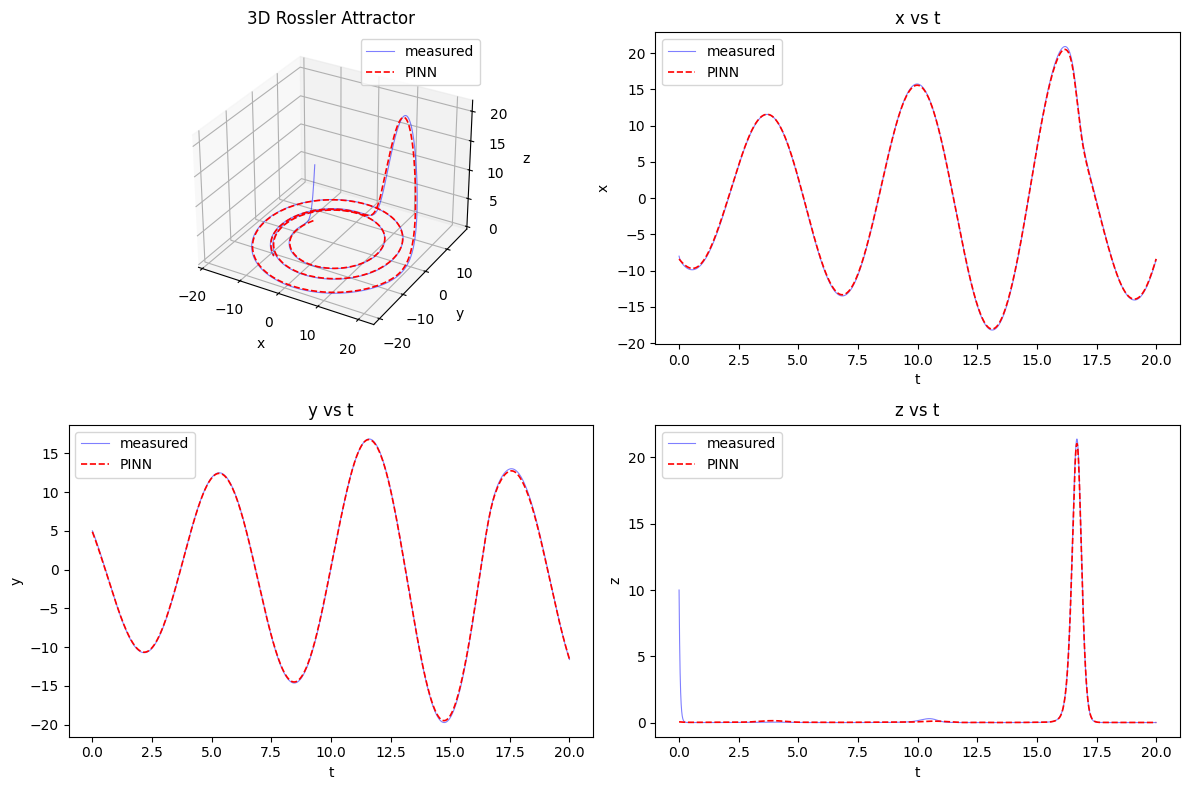

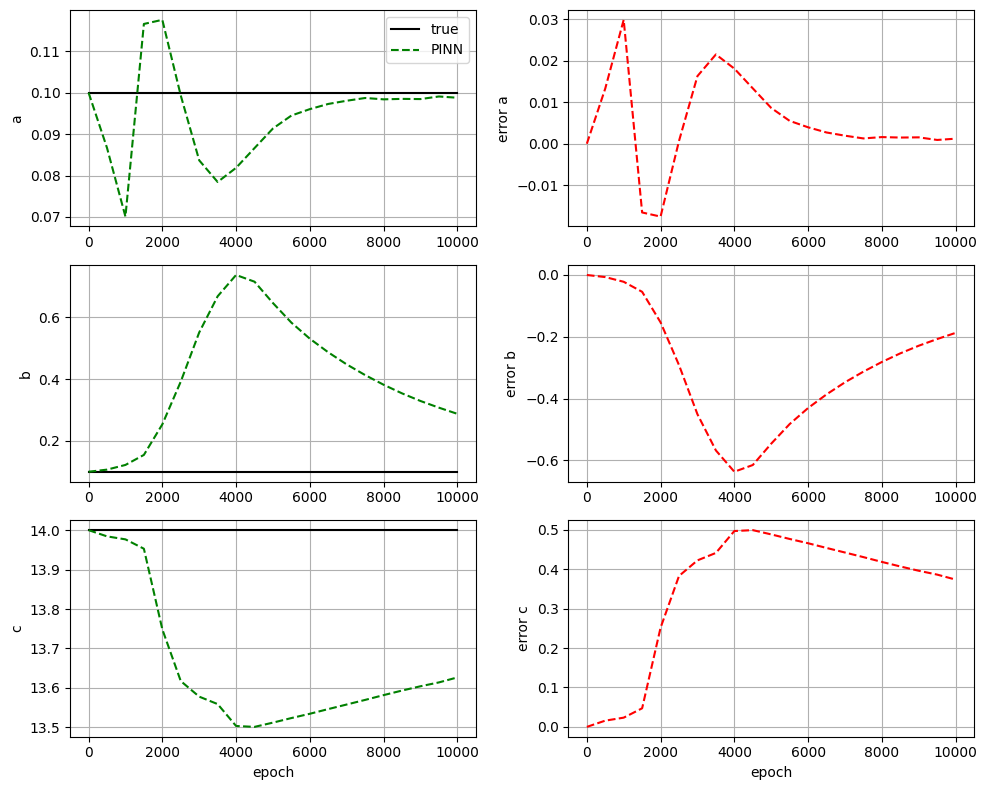

In [7]:
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(221, projection='3d')
ax1.plot(measured[:, 0], measured[:, 1], measured[:, 2], 'b', linewidth=0.8, alpha=0.5)
ax1.plot(pred[:, 0], pred[:, 1], pred[:, 2], 'r--', linewidth=1.2)
ax1.set_title('3D Rossler Attractor')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.legend(['measured', 'PINN'])

ax2 = fig.add_subplot(222)
ax2.plot(t, measured[:, 0], 'b', linewidth=0.8, alpha=0.5)
ax2.plot(t, pred[:, 0], 'r--', linewidth=1.2)
ax2.set_title('x vs t')
ax2.set_xlabel('t')
ax2.set_ylabel('x')
ax2.legend(['measured', 'PINN'])

ax3 = fig.add_subplot(223)
ax3.plot(t, measured[:, 1], 'b', linewidth=0.8, alpha=0.5)
ax3.plot(t, pred[:, 1], 'r--', linewidth=1.2)
ax3.set_title('y vs t')
ax3.set_xlabel('t')
ax3.set_ylabel('y')
ax3.legend(['measured', 'PINN'])

ax4 = fig.add_subplot(224)
ax4.plot(t, measured[:, 2], 'b', linewidth=0.8, alpha=0.5)
ax4.plot(t, pred[:, 2], 'r--', linewidth=1.2)
ax4.set_title('z vs t')
ax4.set_xlabel('t')
ax4.set_ylabel('z')
ax4.legend(['measured', 'PINN'])

plt.tight_layout()
plt.show()

history_arr = np.array(history)
if len(history_arr) > 0:
    fig, axs = plt.subplots(3, 2, figsize=(10, 8))
    names = ['a', 'b', 'c']
    true_values = [a_true, b_true, c_true]
    learned_cols = [4, 5, 6]

    for i, (name, true_value, col) in enumerate(zip(names, true_values, learned_cols)):
        axs[i, 0].plot(history_arr[:, 0], true_value * np.ones_like(history_arr[:, 0]), 'k', label='true')
        axs[i, 0].plot(history_arr[:, 0], history_arr[:, col], 'g--', label='PINN')
        axs[i, 0].set_ylabel(name)
        axs[i, 0].grid(True)
        if i == 0:
            axs[i, 0].legend()

        axs[i, 1].plot(history_arr[:, 0], true_value - history_arr[:, col], 'r--')
        axs[i, 1].set_ylabel(f'error {name}')
        axs[i, 1].grid(True)

    axs[-1, 0].set_xlabel('epoch')
    axs[-1, 1].set_xlabel('epoch')
    plt.tight_layout()
    plt.show()

**Optional LBFGS refinement**

Run this cell after Adam training for a closer fit. It evaluates all time points, so it can be slower for this 20,000-sample dataset.

In [ ]:
RUN_LBFGS = False

if RUN_LBFGS:
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=300, tolerance_grad=1e-7, tolerance_change=1e-9)

    def closure():
        lbfgs.zero_grad()
        y_hat_norm, y_hat, a, b, c = model(t_train)
        loss_data = torch.mean((y_hat_norm - y_train) ** 2)

        x = y_hat[:, 0:1]
        y = y_hat[:, 1:2]
        z = y_hat[:, 2:3]
        dx_dt = torch.autograd.grad(x, t_train, grad_outputs=torch.ones_like(x), create_graph=True)[0] * dt_norm_dt
        dy_dt = torch.autograd.grad(y, t_train, grad_outputs=torch.ones_like(y), create_graph=True)[0] * dt_norm_dt
        dz_dt = torch.autograd.grad(z, t_train, grad_outputs=torch.ones_like(z), create_graph=True)[0] * dt_norm_dt

        r1 = dx_dt - (-y - z)
        r2 = dy_dt - (x + a * y)
        r3 = dz_dt - (b + z * (x - c))
        loss_physics = torch.mean(r1 ** 2 + r2 ** 2 + r3 ** 2)
        loss = lambda_data * loss_data + lambda_physics * loss_physics
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    print('Final LBFGS loss:', float(final_loss))